# Assignment 2

### Dominik Hołoś
### Maria Nowacka

In [3]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=84ba0489513e8729d55b556b8072d8c787caa281913129b88a5fa0343d7fc47a
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
import torch, torch.nn.functional as F
import numpy as np, matplotlib.pyplot as plt, seaborn as sns, warnings, os, re
from pathlib import Path
from PIL import Image
from torchvision import models, transforms
from lime import lime_image
from skimage.segmentation import mark_boundaries
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset
from huggingface_hub import login
warnings.filterwarnings('ignore')
cool_number = 17
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

### 2.2 LIME for Image Classification (25 points)
Use a pre-trained ResNet model on ImageNet:
* Select 5 images from different classes.
* Apply LIME to explain each prediction.
* Visualize superpixels that contribute most to predictions.
* Discuss whether explanations align with human intuition


In [ ]:
!pip install -r requirements.txt

In [ ]:
#1. load the pre-trained ResNet model (ResNet18)
weights = models.ResNet18_Weights.DEFAULT #you can also try ResNet50: larger but slower
model = models.resnet18(weights=weights)
model.eval()
categories = weights.meta["categories"]

# 2 load 5 pictures
image_dir = '/Users/marysia/Desktop/applied/ml/applied/images'
img_files = sorted([str(Path(image_dir) / f) for f in os.listdir(image_dir)
                    if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

selected_paths = img_files[:5]  # select first 5 (ensure they are from different classes if possible)

explainer = lime_image.LimeImageExplainer(random_state=cool_number)

def predict_fn(images):
    # images: list/array of HxWx3 uint8
    batch = torch.stack([preprocess(Image.fromarray(im.astype(np.uint8))) for im in images]).to('cpu')
    with torch.no_grad():
        out = model(batch)
        probs = F.softmax(out, dim=1).cpu().numpy()
    return probs

def visualize_explanation(explanation, img_array, top_class, categories, top_k=3, num_features=10):
    # show original and LIME mask (positive contributions) and overlay top_k superpixels
    plt.figure(figsize=(12,5))

    plt.subplot(1,3,1)
    plt.imshow(img_array)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,3,2)
    explained_img_pos, mask_pos = explanation.get_image_and_mask(
        top_class, positive_only=False, num_features=num_features, hide_rest=False
    )
    plt.imshow(mark_boundaries(explained_img_pos/255.0, mask_pos))
    plt.title("LIME")
    plt.axis('off')

    # build overlay of top_k contributing superpixels by weight
    segs = explanation.segments
    exp_map = dict(explanation.local_exp[top_class])  # list of (superpixel_id, weight)
    # select top_k positive superpixels
    pos_feats = sorted([ (fid, w) for fid,w in exp_map.items() if w>0 ],
                       key=lambda x: -x[1])[:top_k]
    mask = np.zeros(segs.shape, dtype=bool)
    for fid, w in pos_feats:
        mask[segs == fid] = True

    overlay = img_array.copy().astype(float) / 255.0
    # dim non-selected regions
    overlay[~mask] *= 0.25

    plt.subplot(1,3,3)
    plt.imshow(mark_boundaries(overlay, mask))
    plt.title(f"Top {top_k} contributing superpixels")
    plt.axis('off')

    plt.suptitle(f"Predicted: {categories[top_class]}")
    plt.show()

    #green = supports prediction, red = contradicts

def superpixel_importance(explanation, top_class):
    exp_map = dict(explanation.local_exp[top_class])  # list of (superpixel_id, weight)
    print("Feature ID | Importance Weight")
    print("----------------------------")
    for feature_id, weight in sorted(exp_map.items(), key=lambda x: -abs(x[1]))[:10]: #top 10 most important superpixels
        print(f"{feature_id:^10} | {weight:.4f}")

# loop through 5 images

def main(p):
    #3. preprocess the image
    img = Image.open(p).convert('RGB')
    img_array = np.array(img.resize((224,224)))
    #4. make a prediction
    preds = predict_fn([img_array])[0]
    top5_idx = preds.argsort()[-5:][::-1]
    print("\nImage:", p)
    for i, idx in enumerate(top5_idx, 1):
        print(f"{i:>2}. {categories[idx]:<30} {preds[idx]*100:6.2f}%")

    #5. get lime explanations
    explanation = explainer.explain_instance(
        img_array,
        predict_fn,
        top_labels=5,
        num_samples=1000,
        random_seed=cool_number
    )
    top_class = explanation.top_labels[0]
    #6. visualize the explanation
    visualize_explanation(explanation, img_array, top_class, categories, top_k=3, num_features=10)

    #7. map of all superpixels
    segments = explanation.segments
    plt.figure(figsize=(5, 5))
    plt.imshow(segments, cmap='nipy_spectral')
    plt.colorbar(label="Superpixel ID")
    plt.title("Map of all Superpixel IDs")

    for label in np.unique(segments):
        y, x = np.where(segments == label)
        plt.text(x.mean(), y.mean(), str(label),
                color='white', weight='bold', ha='center', va='center')

    plt.axis('off')
    plt.show()
    #8. importance weights for all superpixels
    superpixel_importance(explanation, top_class)


Image: /Users/marysia/Desktop/applied/ml/applied/images/093.jpg
 1. barbell                         92.50%
 2. plunger                          3.00%
 3. dumbbell                         2.23%
 4. spindle                          1.91%
 5. screwdriver                      0.26%


100%|██████████| 1000/1000 [00:21<00:00, 46.52it/s]


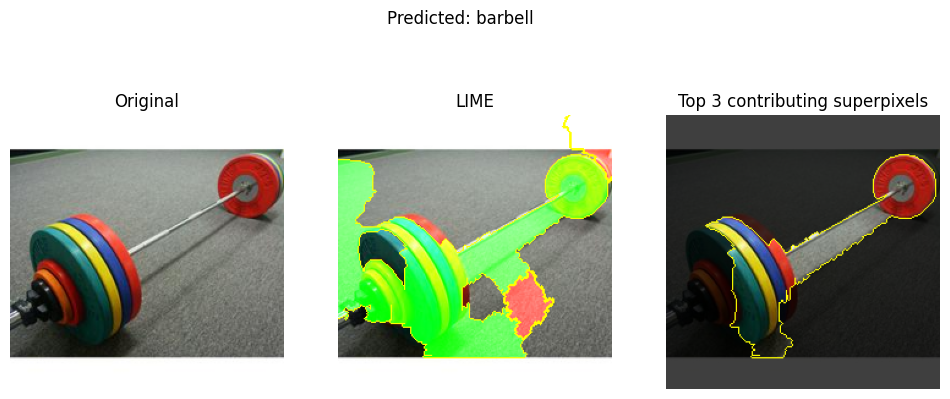

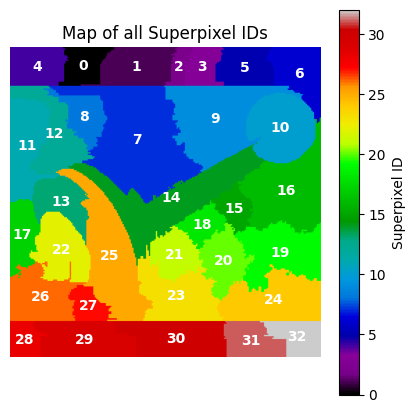

Feature ID | Importance Weight
----------------------------
    10     | 0.2855
    25     | 0.2172
    14     | 0.1966
    22     | 0.1581
    17     | 0.1420
    23     | 0.0790
    6      | -0.0615
    18     | 0.0453
    11     | 0.0419
    20     | -0.0314


In [ ]:
main(selected_paths[0])

* Prediction: correct
* Explanation: reasonable, plates give away what the object is (random fragment 'contradicing' that prediction a bit absurd tho)
* Verdict: LIME aligns with human intuition


Image: /Users/marysia/Desktop/applied/ml/applied/images/104.jpg
 1. Arctic fox                      99.79%
 2. white wolf                       0.10%
 3. kit fox                          0.06%
 4. Samoyed                          0.04%
 5. grey fox                         0.01%


100%|██████████| 1000/1000 [00:20<00:00, 48.56it/s]


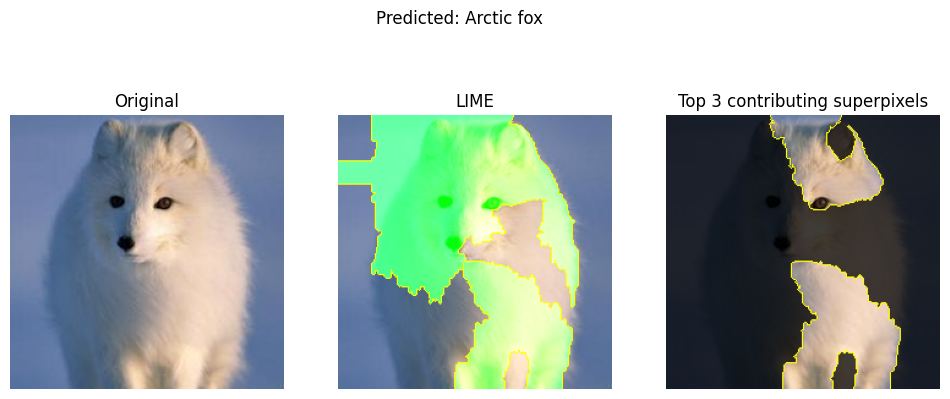

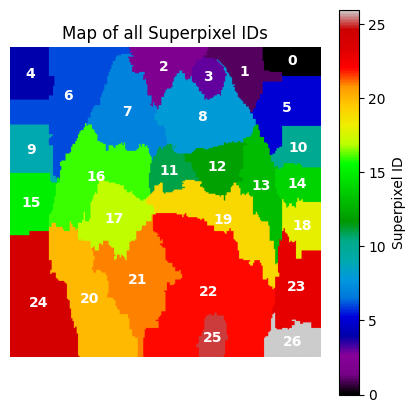

Feature ID | Importance Weight
----------------------------
    8      | 0.5419
    2      | 0.2109
    22     | 0.1738
    7      | 0.1302
    16     | 0.1113
    11     | 0.1065
    3      | 0.1025
    6      | 0.0697
    17     | 0.0569
    13     | 0.0494


In [ ]:
main(selected_paths[1])

* Prediction: correct
* Explanation: fur and ears are important, which makes sense, but the nose and whole face would be more intuitive for a human
* Verdict: LIME somehow aligns with human intuition


Image: /Users/marysia/Desktop/applied/ml/applied/images/261.jpg
 1. bow tie                         99.88%
 2. muzzle                           0.05%
 3. Windsor tie                      0.02%
 4. brassiere                        0.02%
 5. hair slide                       0.01%


100%|██████████| 1000/1000 [00:20<00:00, 48.04it/s]


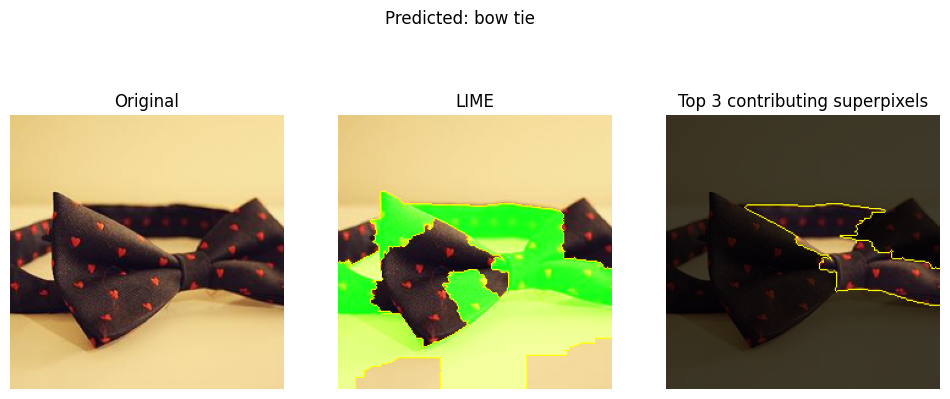

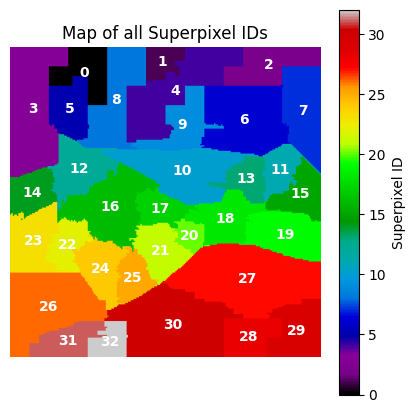

Feature ID | Importance Weight
----------------------------
    10     | 0.2484
    19     | 0.2111
    18     | 0.1949
    21     | 0.1752
    27     | 0.1579
    30     | 0.1386
    13     | 0.1231
    12     | 0.1084
    23     | 0.1065
    26     | 0.0952


In [ ]:
main(selected_paths[2])

* Prediction: correct
* Explanation: doesn't make much sense for a human, the shape of the main part would give it away way faster then the pixels chosen by the model
* Verdict: LIME doesn't align with human intuition


Image: /Users/marysia/Desktop/applied/ml/applied/images/522.jpg
 1. abacus                          99.99%
 2. croquet ball                     0.01%
 3. maraca                           0.00%
 4. dumbbell                         0.00%
 5. confectionery                    0.00%


100%|██████████| 1000/1000 [00:19<00:00, 50.00it/s]


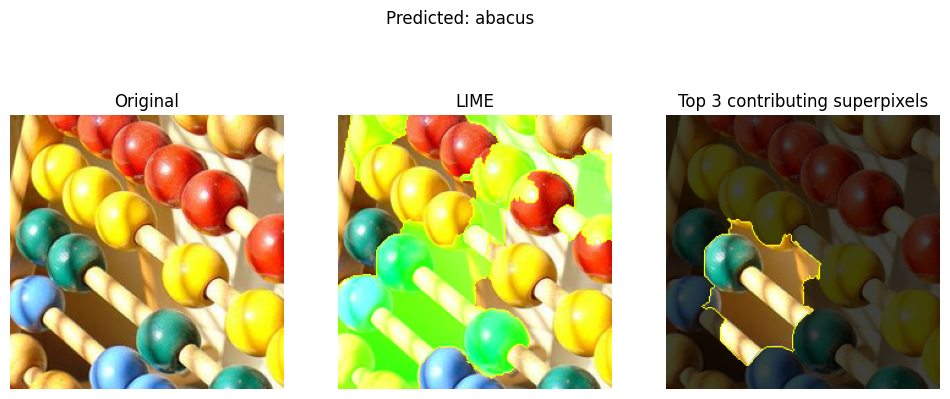

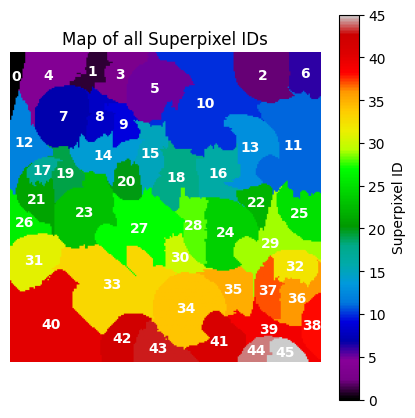

Feature ID | Importance Weight
----------------------------
    33     | 0.3182
    27     | 0.2688
    23     | 0.2241
    34     | 0.1665
    40     | 0.1658
    10     | 0.1339
    31     | 0.1009
    18     | 0.0914
    4      | 0.0848
    11     | 0.0723


In [ ]:
main(selected_paths[3])

* Prediction: correct
* Explanation: reasonable
* Verdict: LIME aligns with human intuition


Image: /Users/marysia/Desktop/applied/ml/applied/images/607.jpg
 1. birdhouse                       98.10%
 2. chime                            1.59%
 3. bell cote                        0.16%
 4. church                           0.05%
 5. ocarina                          0.02%


100%|██████████| 1000/1000 [00:19<00:00, 50.88it/s]


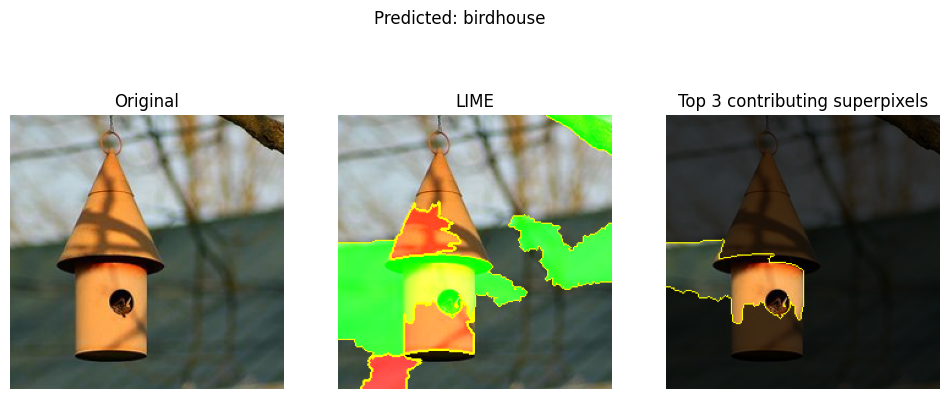

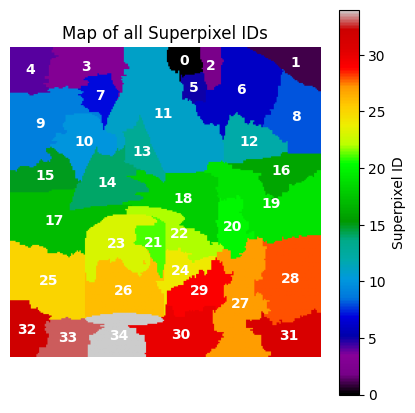

Feature ID | Importance Weight
----------------------------
    23     | 0.3690
    17     | 0.0828
    21     | 0.0811
    22     | 0.0693
    1      | 0.0546
    26     | -0.0507
    14     | -0.0478
    19     | 0.0459
    33     | -0.0434
    25     | 0.0390


In [ ]:
main(selected_paths[4])

* Prediction: correct
* Explanation: reasonable (the hole, the background makes sense, although the 'contradicting' superpixels a bit random)
* Verdict: LIME somehow aligns with human intuition

### 2.4 Attention Visualization (20 points)
Use a pre-trained BERT model for sentiment analysis:
* Analyze movie reviews from IMDB.
* Visualize attention weights for 5 reviews.
* Identify which words contribute most to sentiment predictions.
* Compare attention patterns for positive vs. negative reviews.

In [ ]:
with open("token.txt", "r", encoding="utf-8") as f:
    token = f.read().strip()
login(token)

In [10]:
del model
import gc
gc.collect()

45

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


--- Analyzing Review ---
Original Review: I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this...
Cleaned review: I love scifi and am willing to put up with a lot Scifi moviesTV are usually underfunded underappreciated and misunderstood I tried to like this I real...
True Sentiment: NEGATIVE
Predicted Sentiment: NEGATIVE
Confidence: 99.90%


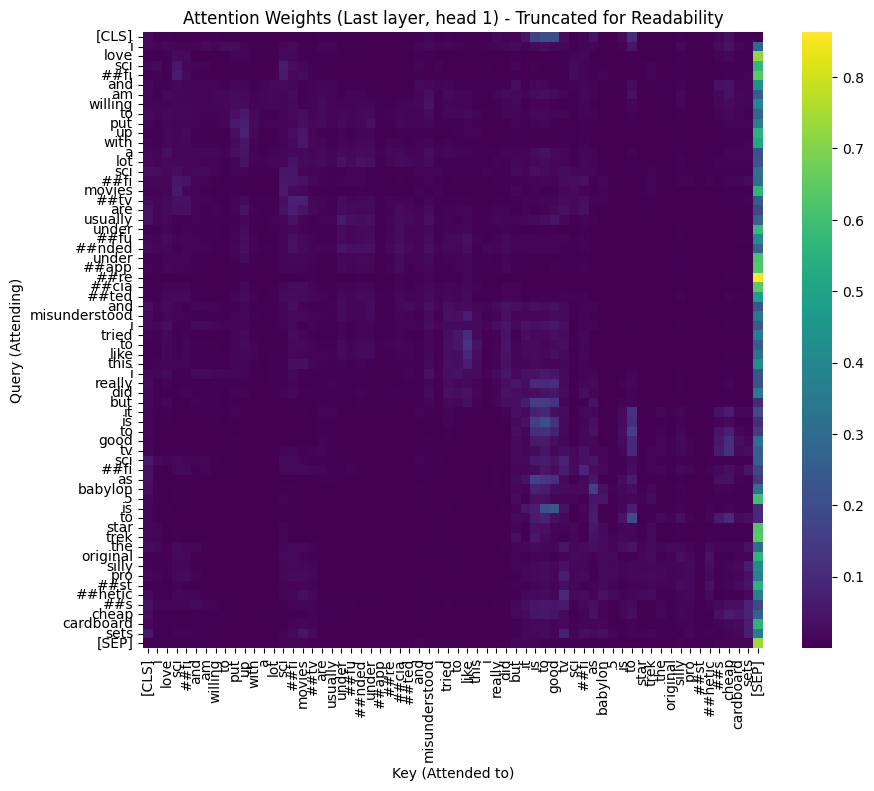

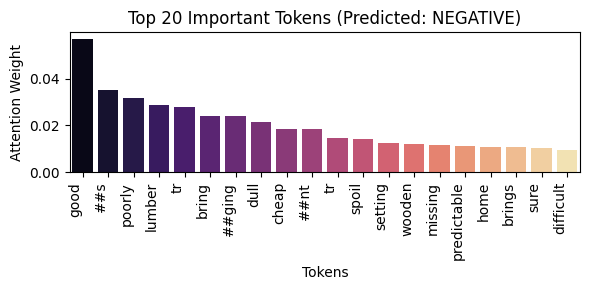


--- Analyzing Review ---
Original Review: Worth the entertainment value of a rental, especially if you like action movies. This one features the usual car chases, fights with the great Van Dam...
Cleaned review: Worth the entertainment value of a rental especially if you like action movies This one features the usual car chases fights with the great Van Damme ...
True Sentiment: NEGATIVE
Predicted Sentiment: NEGATIVE
Confidence: 95.84%


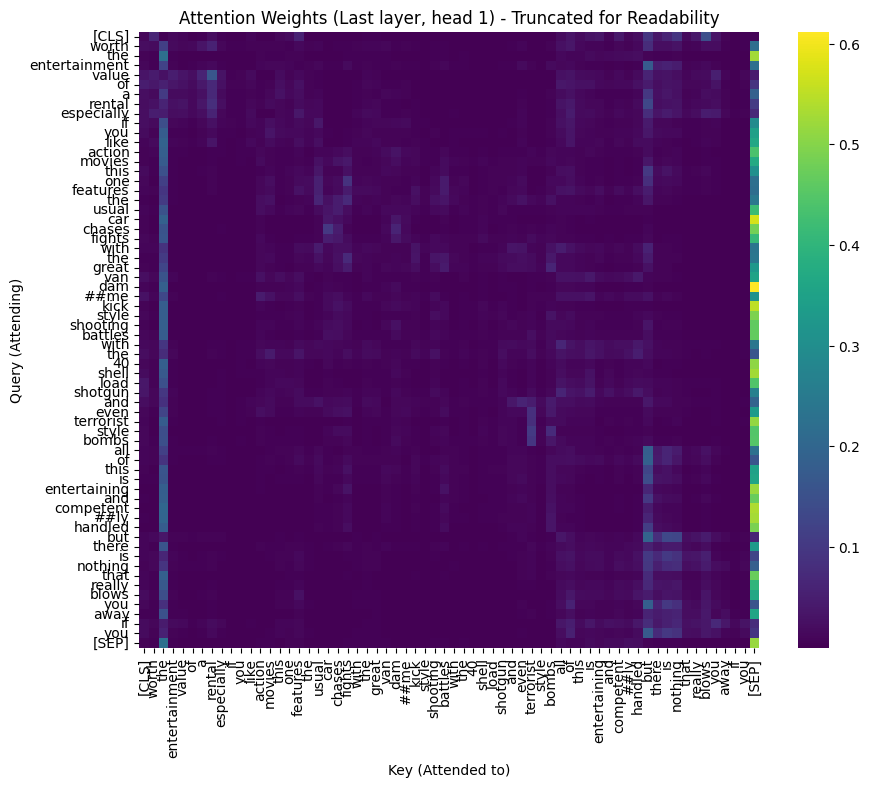

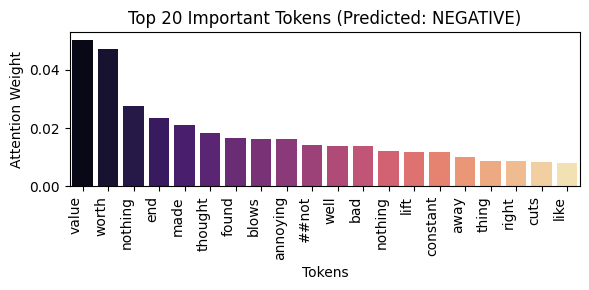


--- Analyzing Review ---
Original Review: Previous reviewer Claudio Carvalho gave a much better recap of the film's plot details than I could. What I recall mostly is that it was just so beaut...
Cleaned review: Previous reviewer Claudio Carvalho gave a much better recap of the films plot details than I could What I recall mostly is that it was just so beautif...
True Sentiment: POSITIVE
Predicted Sentiment: POSITIVE
Confidence: 99.96%


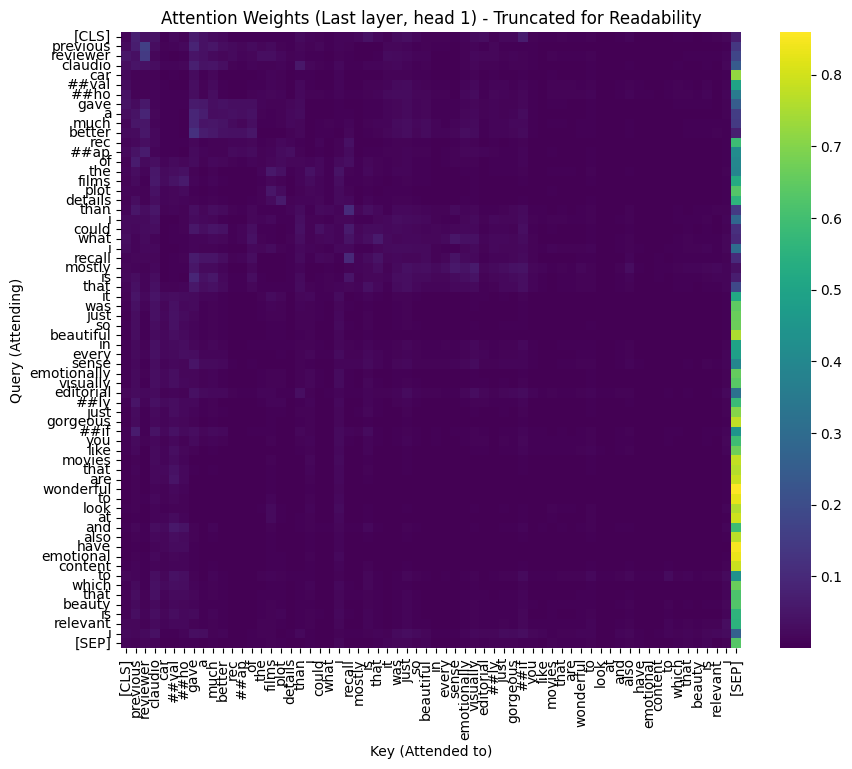

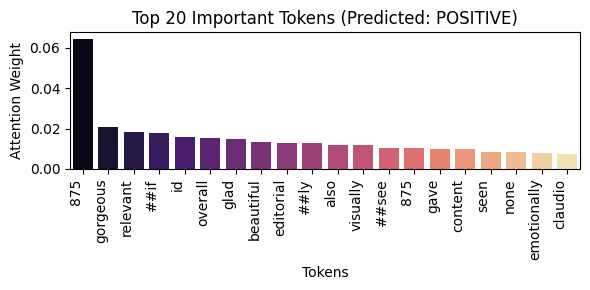


--- Analyzing Review ---
Original Review: CONTAINS "SPOILER" INFORMATION. Watch this director's other film, "Earth", at some point. It's a better film, but this one isn't bad just different.<b...
Cleaned review: CONTAINS SPOILER INFORMATION Watch this directors other film Earth at some point Its a better film but this one isnt bad just differentA rare feminist...
True Sentiment: POSITIVE
Predicted Sentiment: POSITIVE
Confidence: 99.43%


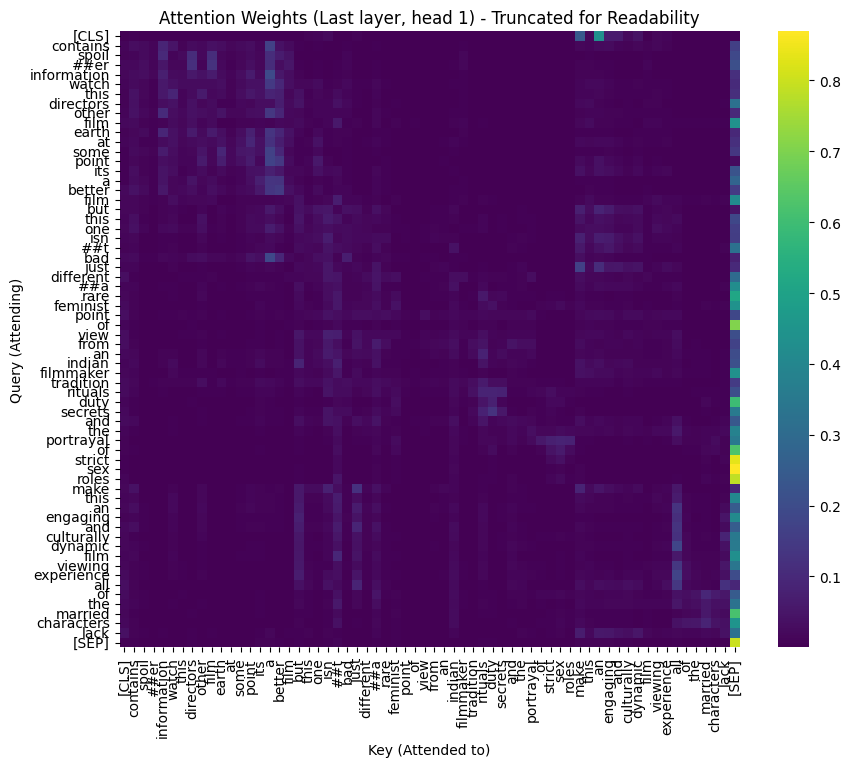

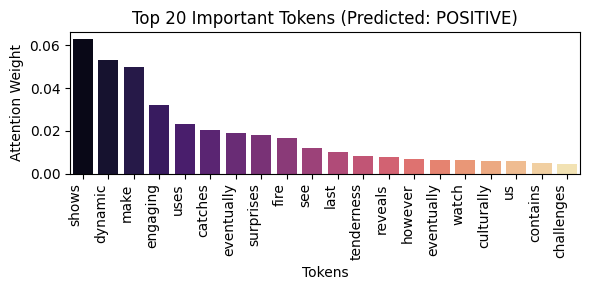


--- Analyzing Review ---
Original Review: This is my first Deepa Mehta film. I saw the film on TV in its Hindi version with its "Sita" character presented as Nita. I also note that it is Radha...
Cleaned review: This is my first Deepa Mehta film I saw the film on TV in its Hindi version with its Sita character presented as Nita I also note that it is Radha who...
True Sentiment: POSITIVE
Predicted Sentiment: NEGATIVE
Confidence: 92.37%


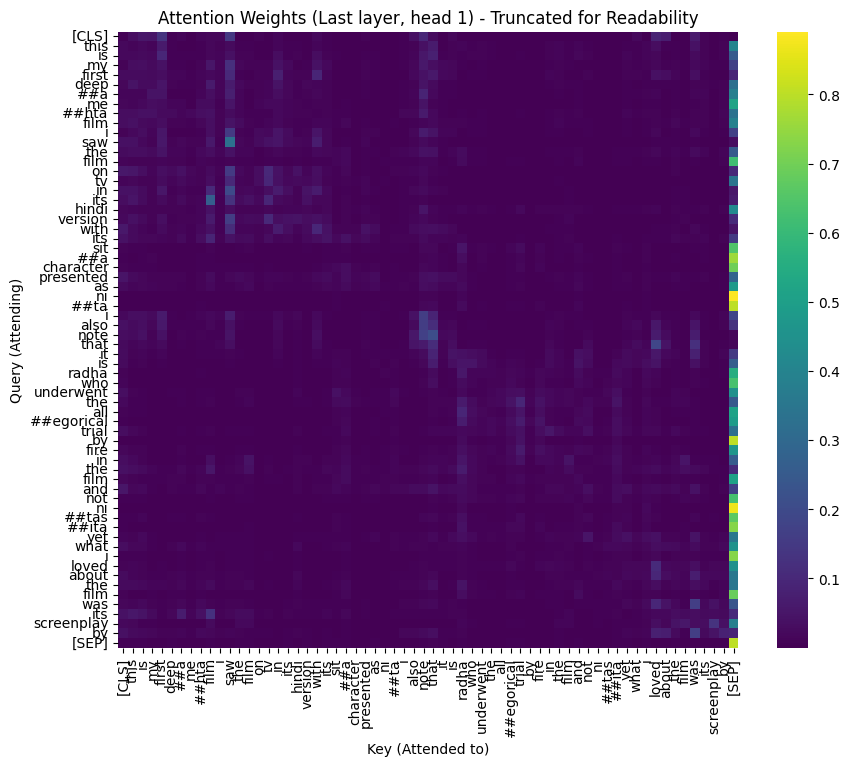

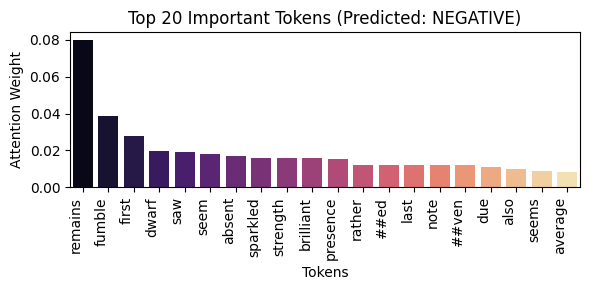

In [ ]:
#1. Load the BERT model (pre-trained for sentiment analysis) with its tokenizer
model_name = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, output_attentions=True)
model.eval()

imdb_test = load_dataset("imdb", split="test")

# Helper function to analyze and visualize attention for a single review
def analyze_review(review_text, review_label, top_k_tokens_for_plot=20):
    print(f"\n--- Analyzing Review ---")

    # Remove HTML tags and '###' signs, then normalize whitespace
    clean_review_text = re.sub(r'<.*?>|#+', '', review_text) # Remove HTML tags and '#'
    clean_review_text = re.sub('\n', '', clean_review_text)
    clean_review_text = re.sub(r'\s+', ' ', clean_review_text).strip() # Normalize whitespace

    # Remove punctuation and hyphens
    clean_review_text = clean_review_text.translate(str.maketrans('', '', string.punctuation.replace('-', '')))
    clean_review_text = clean_review_text.replace('-', '')

    print(f"Original Review: {review_text[:150]}...")
    print(f"Cleaned review: {clean_review_text[:150]}...")
    sentiment_label = "POSITIVE" if review_label == 1 else "NEGATIVE"
    print(f"True Sentiment: {sentiment_label}")
    #2. Prepare the input - use max_length=512 for full analysis, but still truncate if review is longer
    inputs = tokenizer(clean_review_text, return_tensors="pt", truncation=True, max_length=512)
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    #3. Forward pass
    with torch.no_grad():
        outputs = model(**inputs)
        attentions = outputs.attentions

    #4. Get the sentiment prediction
    logits = outputs.logits
    probs = F.softmax(logits, dim=-1)
    prediction_idx = torch.argmax(probs).item()
    predicted_label = model.config.id2label[prediction_idx]
    confidence = probs[0][prediction_idx].item()

    print(f"Predicted Sentiment: {predicted_label}")
    print(f"Confidence: {confidence:.2%}")

    # 5. Visualize attention for [CLS] token (heatmap for raw attention matrix - optional and potentially large)
    # If the sequence length is too long, this plot becomes unreadable. We will keep max_length at 64 for this specific plot.
    # For the heatmap, we will use a truncated version to keep it readable, as discussed earlier.
    heatmap_inputs = tokenizer(clean_review_text, return_tensors="pt", truncation=True, max_length=64)
    heatmap_tokens = tokenizer.convert_ids_to_tokens(heatmap_inputs["input_ids"][0])

    # Rerun model with truncated input for heatmap visualization only
    with torch.no_grad():
        heatmap_outputs = model(**heatmap_inputs)
        heatmap_attentions = heatmap_outputs.attentions

    head = 0 #0,...,11
    attention_matrix = heatmap_attentions[-1][0, head].detach().numpy() #-1 denotes the last layer (distilbert has 6 layers, 12 heads)

    plt.figure(figsize=(10, 8))
    sns.heatmap(attention_matrix, xticklabels=heatmap_tokens, yticklabels=heatmap_tokens,
                annot=False, cmap="viridis")
    plt.title(f"Attention Weights (Last layer, head {head+1}) - Truncated for Readability")
    plt.xlabel("Key (Attended to)")
    plt.ylabel("Query (Attending)")
    plt.show()

    #6. Calculate average attention for [CLS] token and all heads using the full input
    last_layer = attentions[-1][0] # attentions is a tuple of (layer, batch, head, seq_len, seq_len)
    avg_attn = last_layer.mean(dim=0)
    cls_attention = avg_attn[0].detach().numpy() # [CLS] token is at index 0

    # Filter out special tokens and stop words for visualization
    processed_tokens = []
    processed_cls_attention = []
    for i, token in enumerate(tokens):
        # NLTK stop words are lowercase, so convert token to lowercase for comparison
        if token not in ['[CLS]', '[SEP]'] and token.lower() not in stop_words:
            processed_tokens.append(token)
            processed_cls_attention.append(cls_attention[i])

    # Sort by attention weight and select top_k_tokens_for_plot
    sorted_indices = np.argsort(processed_cls_attention)[::-1] # Sort in descending order
    top_k_tokens = [processed_tokens[i] for i in sorted_indices[:top_k_tokens_for_plot]]
    top_k_cls_attention = [processed_cls_attention[i] for i in sorted_indices[:top_k_tokens_for_plot]]

    plt.figure(figsize=(6, 3))
    x_pos = range(len(top_k_tokens))
    sns.barplot(x=x_pos, y=top_k_cls_attention, palette="magma")
    plt.title(f"Top {top_k_tokens_for_plot} Important Tokens (Predicted: {predicted_label})")
    plt.xticks(x_pos, top_k_tokens, rotation=90, ha="right")
    plt.ylabel("Attention Weight")
    plt.xlabel("Tokens")
    plt.tight_layout()
    plt.show()

# Select 5 reviews
selected_reviews = [
    imdb_test[0], # Negative
    imdb_test[1], # Negative
    imdb_test[12500], # Positive
    imdb_test[12501], # Positive
    imdb_test[12502]  # Positive
]

# Analyze each selected review
for review in selected_reviews:
    analyze_review(review['text'], review['label'])